# 08. 偏微分方程式とスペクトル法

**この章のゴール**: フーリエ基底で展開すると **時間発展がモードごとに分離** されることを使い、
熱方程式・波動方程式を「各周波数の常微分方程式」に還元して解く。微分が周波数領域で
$ik$ 倍になることが心臓部。

## Big Picture

周期境界で $u(x,t)=\sum_k \hat u_k(t)\,e^{ikx}$ と展開すると、空間微分は

$$ \frac{\partial}{\partial x}e^{ikx} = ik\,e^{ikx} $$

なので、線形・定数係数の PDE は **各モード $\hat u_k$ の独立な ODE** に分かれます。
モードごとに閉じた形で解けるので、空間微分の誤差がない高精度解法(スペクトル法)になります。

## Problem

熱方程式

$$ \frac{\partial u}{\partial t} = \alpha\frac{\partial^2 u}{\partial x^2} $$

と波動方程式

$$ \frac{\partial^2 u}{\partial t^2} = c^2\frac{\partial^2 u}{\partial x^2} $$

を、差分格子ではなくフーリエ係数の上で解きます。

## Intuition / Definition — 微分は $ik$ 倍

熱方程式を Fourier 変換すると、各モードは

$$ \frac{d\hat u_k}{dt} = -\alpha k^2\,\hat u_k
   \quad\Longrightarrow\quad \hat u_k(t)=\hat u_k(0)\,e^{-\alpha k^2 t}. $$

$|k|$ が大きい(高周波・細かい構造)ほど $e^{-\alpha k^2 t}$ で **速く消える**。
波動方程式では $\hat u_k(t)=\hat u_k(0)\cos(c|k|t)+\hat v_k(0)\frac{\sin(c|k|t)}{c|k|}$ で、
モードは減衰せず **振動** します。

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

## Computation 1 — スペクトル微分の精度

まず「微分を $ik$ 倍で計算する」だけで、滑らかな周期関数の微分が
**差分法より桁違いに正確**になることを確認します。

In [2]:
# Spectral differentiation vs finite difference on a smooth periodic function.
L = 2 * np.pi
N = 64
x = np.linspace(0, L, N, endpoint=False)
u = np.exp(np.sin(x))
du_exact = np.cos(x) * np.exp(np.sin(x))

du_spec = spectral.spectral_derivative(u, L)
du_fd = np.gradient(u, x[1] - x[0])             # 2nd-order central difference

print(f"spectral  max error: {np.max(np.abs(du_spec - du_exact)):.2e}")
print(f"finite-diff max error: {np.max(np.abs(du_fd - du_exact)):.2e}")

spectral  max error: 1.09e-14
finite-diff max error: 4.90e-02


## Computation 2 — 熱方程式は高周波を先に消す

初期条件に低周波と高周波を混ぜておくと、時間とともに **高周波のさざ波が先に消えて**
滑らかになる様子が見えます。

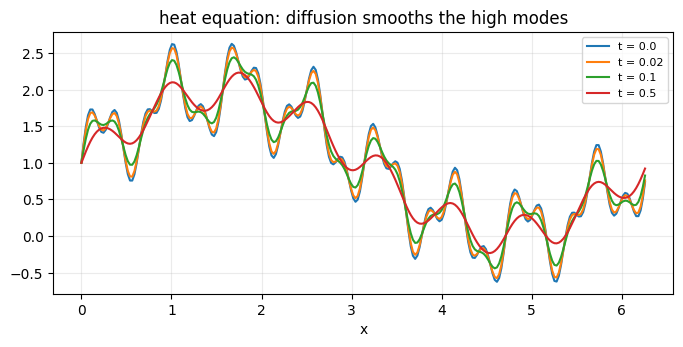

In [3]:
# Heat equation smooths: high-frequency ripples vanish first.
L = 2 * np.pi
N = 256
x = np.linspace(0, L, N, endpoint=False)
u0 = 1.0 + np.sin(x) + 0.5 * np.sin(8 * x) + 0.3 * np.sin(20 * x)
alpha = 0.02
times = [0.0, 0.02, 0.1, 0.5]

fig, ax = plt.subplots(figsize=(8, 3.4))
for ti in times:
    ax.plot(x, spectral.solve_heat_spectral(u0, L, alpha, ti), label=f"t = {ti}")
ax.set_xlabel("x"); ax.set_title("heat equation: diffusion smooths the high modes")
ax.legend(fontsize=8); ax.grid(alpha=.25)
plt.show()

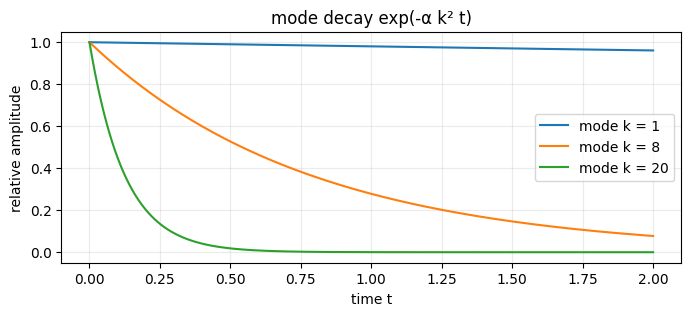

In [4]:
# Per-mode amplitude decays like exp(-α k² t): high k disappears far faster.
ts = np.linspace(0, 2, 200)
fig, ax = plt.subplots(figsize=(8, 3))
for k in [1, 8, 20]:
    ax.plot(ts, np.exp(-alpha * k**2 * ts), label=f"mode k = {k}")
ax.set_xlabel("time t"); ax.set_ylabel("relative amplitude")
ax.set_title("mode decay exp(-α k² t)"); ax.legend(); ax.grid(alpha=.25)
plt.show()

## Invariant / Energy — 熱: 質量保存・エネルギー散逸

$k=0$ モード($\hat u_0$)は $e^{-\alpha\cdot 0\cdot t}=1$ で不変。つまり **総量(質量)
$\int u\,dx$ は保存**します。一方で **エネルギー $\int u^2\,dx$ は単調に減少**(散逸)します。

In [5]:
# Mass (∫u dx) is conserved; energy (∫u² dx) dissipates.
print(f"{'t':>6} {'mass ∫u':>12} {'energy ∫u²':>14}")
for ti in [0.0, 0.05, 0.2, 1.0]:
    u = spectral.solve_heat_spectral(u0, L, alpha, ti)
    print(f"{ti:6.2f} {np.trapezoid(u, x):12.4f} {np.trapezoid(u**2, x):14.4f}")

     t      mass ∫u     energy ∫u²
  0.00       6.2619        10.4740
  0.05       6.2612        10.2167
  0.20       6.2602         9.8604
  1.00       6.2593         9.3390


## Computation 3 — 波動方程式: 山が左右へ割れて進む

局在した初期変位(速度 0)は、**左右に半分ずつ進む波** に分かれます(d'Alembert)。
熱と違い、各モードは減衰せず振動するので、形を保って伝わります。

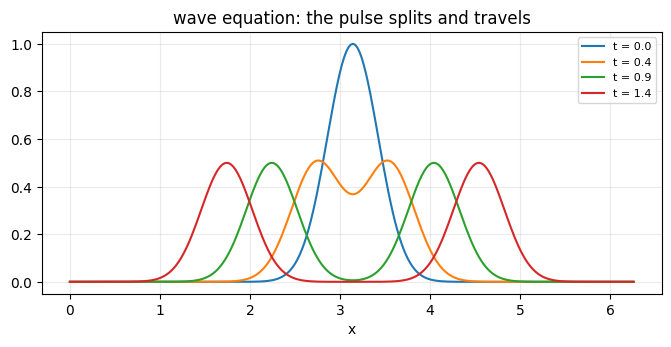

In [6]:
# Wave equation: a localized bump splits into left- and right-moving halves.
L = 2 * np.pi
N = 256
x = np.linspace(0, L, N, endpoint=False)
u0 = np.exp(-((x - np.pi) ** 2) / (2 * 0.08))   # localized pulse
v0 = np.zeros_like(x)
c = 1.0

fig, ax = plt.subplots(figsize=(8, 3.4))
for ti in [0.0, 0.4, 0.9, 1.4]:
    ax.plot(x, spectral.solve_wave_spectral(u0, v0, L, c, ti), label=f"t = {ti}")
ax.set_xlabel("x"); ax.set_title("wave equation: the pulse splits and travels")
ax.legend(fontsize=8); ax.grid(alpha=.25)
plt.show()

## Failure Mode — 周期境界・非線形・aliasing

- スペクトル法は **周期境界** を前提にします。非周期問題にそのまま使うと端で振動
  (Gibbs)が出る → Chebyshev など別の基底が必要。
- 非線形項(例 $u u_x$)は積で **高周波を生み**、折り返して低周波を汚す(aliasing)。
  対策が **dealiasing**(2/3 ルールなど)。
- 時間積分自体は別問題(ここでは線形なので各モード解析解を使い、時間離散誤差ゼロ)。

## Application — スペクトル法が活きる場所

乱流の直接数値計算(DNS)、地球流体、量子力学の時間発展(split-step Fourier)など、
**滑らかな解 × 周期的(または周期化できる)領域**でスペクトル法は最高精度を発揮します。
05 章の畳み込み定理(微分・畳み込みが周波数で積になる)と同じ原理の延長です。

## Exercises

1. **解析解照合**: 単一モード $u_0=\sin(mx)$ の熱方程式解が $e^{-\alpha m^2 t}\sin(mx)$ に
   一致することを `solve_heat_spectral` で確かめよ。
2. **収束次数**: スペクトル微分の誤差を $N$ に対してプロットし、差分法の多項式収束と比べよ。
3. **定在波**: $u_0=\sin(2x),\ v_0=0$ の波動解が $\cos(2ct)\sin(2x)$ になることを確認せよ。
4. **Poisson**: `spectral.solve_poisson_spectral` で $u''=f$ を解き、$u$ を 2 回微分して $f$ に戻るか確かめよ。

## Advanced Notes

```{admonition} なぜ「スペクトル」精度なのか
:class: note
滑らかな周期関数のフーリエ係数は指数的に減衰する(03 章)。微分を $ik$ 倍で行うと、
打ち切り誤差も指数的に小さい — これが **spectral accuracy**(代数次数でなく指数収束)。
差分法の $O(h^p)$ とは質的に異なる。
```

- 熱方程式の解は任意の初期データを瞬時に $C^\infty$ にする(平滑化作用)。
- 波動方程式はエネルギー $\tfrac12\int(u_t^2+c^2u_x^2)dx$ を保存(各モードの振動の総和)。
- Laplace 方程式 $u_{xx}+u_{yy}=0$ も、各方向にフーリエ展開すると $\hat u_k$ の
  常微分方程式 $\hat u_k''=k^2\hat u_k$(指数解)に分離できる。